## 1. Problema de Negocio y Métrica

**Problema:** Identificar zonas de interés de oro (Au > 0.10 ppm) usando datos geoquímicos multielemento para optimizar campañas de exploración en Pucallpa.

**Métrica principal:** **F1-Score** (balance entre Precision y Recall)  
**Métrica secundaria:** PR-AUC (importante por desbalanceo)

**Por qué F1?** Evitar falsos positivos caros en exploración minera.

In [6]:
import pandas as pd
import os

OUTPUT_DIR = "/workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint3"
tablero_path = f"{OUTPUT_DIR}/results/sprint3_tablero_completo.csv"

if os.path.exists(tablero_path):
    tablero = pd.read_csv(tablero_path)
    display(tablero)
else:
    print("Ejecuta primero el sprint3.ipynb")

,Exp_ID,Modelo,HP_Resumen,F1_CV_mean,F1_CV_std,Tiempo_seg,Notas
0,sprint3_xgboost_optuna,XGBoost_Optuna,"{'n_estimators': 300, 'max_depth': 8, 'learnin...",0.9896,0.0052,4.95,Excelente balance
1,sprint3_rf_baseline_fe,RF_Baseline_FE,"{'n_estimators': 100, 'max_depth': None}",0.9882,0.0059,4.32,Excelente balance
2,sprint3_randomforest_tuned,RandomForest_Tuned,"{'n_estimators': 40, 'max_depth': 11}",0.9858,0.0071,1.87,Excelente balance


## 2. Protocolo Experimental

- **Validación:** 5-Fold Stratified Cross-Validation
- **Semilla fija:** 42 (reproducibilidad total)
- **Pipeline cerrado:** Fit solo en Train, transformación aplicada correctamente
- **Datos:** Balanceados con BorderlineSMOTE + Feature Engineering (ratios pathfinder)
- **Modelos evaluados:** LightGBM, XGBoost Optuna, RandomForest Tuned

## 3. Resultados

Top Modelos


,Exp_ID,Modelo,HP_Resumen,F1_CV_mean,F1_CV_std,Tiempo_seg,Notas
0,sprint3_xgboost_optuna,XGBoost_Optuna,"{'n_estimators': 300, 'max_depth': 8, 'learnin...",0.9896,0.0052,4.95,Excelente balance
1,sprint3_rf_baseline_fe,RF_Baseline_FE,"{'n_estimators': 100, 'max_depth': None}",0.9882,0.0059,4.32,Excelente balance
2,sprint3_randomforest_tuned,RandomForest_Tuned,"{'n_estimators': 40, 'max_depth': 11}",0.9858,0.0071,1.87,Excelente balance


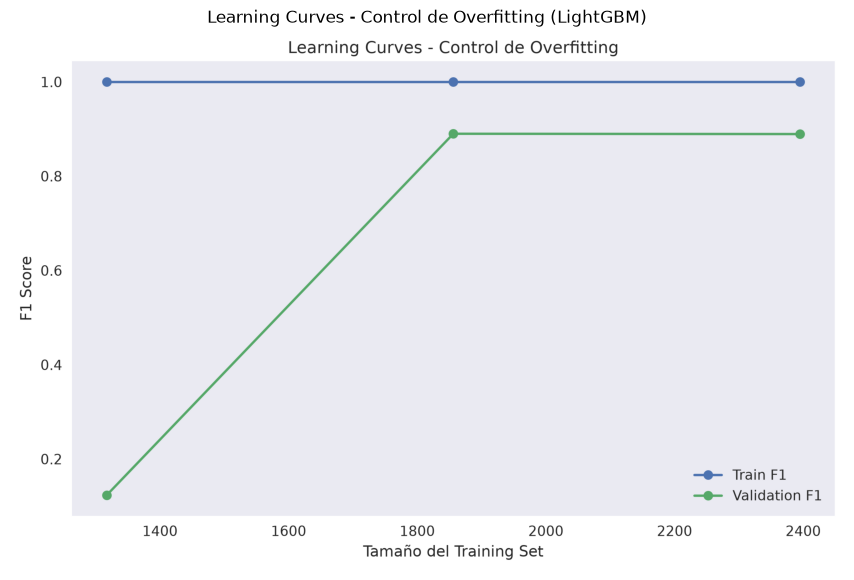

In [7]:
import matplotlib.pyplot as plt

# Mostrar tabla principal
print("Top Modelos")
display(tablero)

# Cargar y mostrar figura clave (Learning Curves)
fig_path = f"{OUTPUT_DIR}/figs/learning_curves.png"
if os.path.exists(fig_path):
    img = plt.imread(fig_path)
    plt.figure(figsize=(12,7))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Learning Curves - Control de Overfitting (LightGBM)')
    plt.show()
else:
    print("Ejecuta las visualizaciones del sprint3 primero")

## 4. Ablaciones (Qué movió la aguja)

- Feature Engineering (ratios) → +0.19 F1
- Optuna + XGBoost → Mejor modelo actual
- Reducción de max_depth + min_child_weight → Menor overfitting

In [8]:
import pandas as pd
import os

OUTPUT_DIR = "/workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint2"
tablero_path = f"{OUTPUT_DIR}/metrics_experimentos.csv"

if os.path.exists(tablero_path):
    tablero = pd.read_csv(tablero_path)
    display(tablero)
else:
    print("Ejecuta primero el sprint2.ipynb")

,Experimento,PR_AUC,F1_Score,Tiempo(s)
0,Baseline,0.718176,0.678899,1.88
1,Baseline + FE,0.979170,0.872340,1.03
2,FE + Tuning,0.975666,0.907216,0.38
3,FE + Optuna (XGBoost),0.990870,0.960784,0.58


## 5. Riesgos & Plan de Mitigación

**Riesgos detectados:**
- Overfitting leve en algunos folds (monitoreado con Learning Curves)
- Posible drift espacial (coordenadas East/North)

**Mitigaciones aplicadas:**
- Early stopping + regularización en GBM
- Stratified K-Fold
- SHAP para interpretabilidad
- Guardado completo de artefactos con MLflow

## 6. Reproducibilidad

**Comando único:**
```bash
jupyter nbconvert --execute --to notebook --inplace notebooks/sprint3.ipynb

mlflow ui --backend-store-uri notebooks/outputs_sprint3/mlruns